In [1]:
!pip install mediapipe

   ---------------------------------------- 0.0/10.9 MB ? eta -:--:--
   ------------------ --------------------- 5.0/10.9 MB 33.5 MB/s eta 0:00:01
   ---------------------------------------- 10.9/10.9 MB 35.8 MB/s  0:00:00
   ---------------------------------------- 0.0/46.5 MB ? eta -:--:--
   --------- ------------------------------ 10.5/46.5 MB 50.4 MB/s eta 0:00:01
   ---------------- ----------------------- 18.6/46.5 MB 46.9 MB/s eta 0:00:01
   ---------------------- ----------------- 25.7/46.5 MB 42.8 MB/s eta 0:00:01
   ------------------------------ --------- 35.1/46.5 MB 42.9 MB/s eta 0:00:01
   -------------------------------------- - 44.3/46.5 MB 43.3 MB/s eta 0:00:01
   ---------------------------------------- 46.5/46.5 MB 39.4 MB/s  0:00:01

  Attempting uninstall: flatbuffers

    Found existing installation: flatbuffers 25.2.10

    Uninstalling flatbuffers-25.2.10:

      Successfully uninstalled flatbuffers-25.2.10

   ---------------------------------------- 0/4 [fla


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib
import matplotlib.pyplot as plt
import cv2
import pandas
import numpy
import json
import os
import pandas as pd
import mediapipe as mp

#ML imports
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from torchvision.models import vit_b_16, ViT_B_16_Weights

from tqdm.auto import tqdm

print("All libraries installed successfully!")

All libraries installed successfully!


d:\My Work\Computer Science Courses and Projects\Envs\DeepGPU\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
Device count: 1
GPU name: NVIDIA GeForce GTX 1650


In [4]:
# Load both JSON files
with open("labels_lumbar_error.json", "r") as f:
    lumbar_data = json.load(f)

with open("labels_torso_angle_error.json", "r") as f:
    torso_data = json.load(f)

# Combine them: if either has error → 1
combined_data = {}

all_keys = set(lumbar_data.keys()).union(torso_data.keys())

for key in all_keys:
    lumbar_val = lumbar_data.get(key, 0)
    torso_val = torso_data.get(key, 0)
    
    combined_data[key] = int(lumbar_val == 1 or torso_val == 1)

# Convert to DataFrame
df = pd.DataFrame(list(combined_data.items()), columns=["frame_id", "error_present"])

print(df.head())

     frame_id  error_present
0  59193_5_14              0
1  59435_1_42              1
2  53279_18_6              0
3  61755_2_45              0
4  59999_9_13              0


In [5]:
df["exercise_name"] = "barbell_row"

In [6]:
# Extract video name
df["video_name"] = df["frame_id"].apply(lambda x: "_".join(x.split("_")[:2]))

# Convert to video-level
video_df = (
    df.groupby(["exercise_name", "video_name"])["error_present"]
    .max()
    .reset_index()
)

print(video_df.head())

  exercise_name video_name  error_present
0   barbell_row   52701_11              1
1   barbell_row    52723_8              0
2   barbell_row    52729_1              1
3   barbell_row    52730_7              1
4   barbell_row    52731_4              1


In [7]:
video_df["error_present"].value_counts()

error_present
0    950
1    928
Name: count, dtype: int64

In [8]:
# Load both JSON files
with open("OHP_error_elbows.json", "r") as f:
    elbows_data = json.load(f)

with open("OHP_error_knees.json", "r") as f:
    knees_data = json.load(f)

# Union of keys from both files
all_keys = set(elbows_data.keys()).union(knees_data.keys())

# Build video-level binary labels
ohp_rows = []
for video_name in all_keys:
    elbows_intervals = elbows_data.get(video_name, [])
    knees_intervals = knees_data.get(video_name, [])
    
    error_present = int(len(elbows_intervals) > 0 or len(knees_intervals) > 0)
    
    ohp_rows.append({
        "exercise_name": "overhead_press",
        "video_name": video_name,
        "error_present": error_present
    })

# Convert to DataFrame
ohp_video_df = pd.DataFrame(ohp_rows)

print(ohp_video_df.head())

    exercise_name video_name  error_present
0  overhead_press    74884_1              1
1  overhead_press    72761_4              1
2  overhead_press    66860_1              1
3  overhead_press    79402_3              1
4  overhead_press    65931_3              1


In [9]:
video_df = pd.concat([video_df, ohp_video_df], ignore_index=True)

In [10]:
video_df.groupby("exercise_name")["error_present"].value_counts().sort_index()

exercise_name   error_present
barbell_row     0                 950
                1                 928
overhead_press  0                1024
                1                1236
Name: count, dtype: int64

In [11]:
# Load both JSON files
with open("Squat_error_knees_inward.json", "r") as f:
    knees_inward_data = json.load(f)

with open("Squat_error_knees_forward.json", "r") as f:
    knees_forward_data = json.load(f)

# Union of keys from both files
all_keys = set(knees_inward_data.keys()).union(knees_forward_data.keys())

# Build video-level binary labels
squat_rows = []
for video_name in all_keys:
    inward_intervals = knees_inward_data.get(video_name, [])
    forward_intervals = knees_forward_data.get(video_name, [])

    error_present = int(len(inward_intervals) > 0 or len(forward_intervals) > 0)

    squat_rows.append({
        "exercise_name": "squat",
        "video_name": video_name,
        "error_present": error_present
    })

# Convert to DataFrame
squat_video_df = pd.DataFrame(squat_rows)

print(squat_video_df.head())

  exercise_name video_name  error_present
0         squat    37839_1              1
1         squat    50204_1              1
2         squat    36772_6              1
3         squat    33207_1              1
4         squat    48459_1              1


In [12]:
video_df = pd.concat([video_df, squat_video_df], ignore_index=True)

In [13]:
video_df.groupby("exercise_name")["error_present"].value_counts().sort_index()

exercise_name   error_present
barbell_row     0                 950
                1                 928
overhead_press  0                1024
                1                1236
squat           0                 474
                1                1149
Name: count, dtype: int64

In [14]:
# Overall
print(video_df["error_present"].value_counts(normalize=True))

# Per exercise
print(
    video_df.groupby("exercise_name")["error_present"]
    .value_counts(normalize=True)
)

error_present
1    0.575074
0    0.424926
Name: proportion, dtype: float64
exercise_name   error_present
barbell_row     0                0.505857
                1                0.494143
overhead_press  1                0.546903
                0                0.453097
squat           1                0.707948
                0                0.292052
Name: proportion, dtype: float64


In [15]:
error_rates = (
    video_df.groupby("exercise_name")["error_present"]
    .mean()
    .sort_values(ascending=False)
)

print(error_rates)

exercise_name
squat             0.707948
overhead_press    0.546903
barbell_row       0.494143
Name: error_present, dtype: float64


In [16]:
video_df["exercise_name"].value_counts()

exercise_name
overhead_press    2260
barbell_row       1878
squat             1623
Name: count, dtype: int64

In [17]:
# 1st iteration of training: Frozen VIT + Fine tuned binary classifier head

video_df

,exercise_name,video_name,error_present
0,barbell_row,52701_11,1
1,barbell_row,52723_8,0
2,barbell_row,52729_1,1
3,barbell_row,52730_7,1
4,barbell_row,52731_4,1
...,...,...,...
5756,squat,46569_11,0
5757,squat,50709_3,1
5758,squat,46334_2,1
5759,squat,46958_6,1


### Doing frame wise analysis first as ViT as best suited for frame wise analysis and will fine tune a binary classifier head on the top of that

In [18]:
# Load both JSON files
with open("labels_lumbar_error.json", "r") as f:
    lumbar_data = json.load(f)

with open("labels_torso_angle_error.json", "r") as f:
    torso_data = json.load(f)

# Combine them: if either has error → 1
combined_data = {}

all_keys = set(lumbar_data.keys()).union(torso_data.keys())

for key in all_keys:
    lumbar_val = lumbar_data.get(key, 0)
    torso_val = torso_data.get(key, 0)
    
    combined_data[key] = int(lumbar_val == 1 or torso_val == 1)

# Convert to DataFrame
frame_df = pd.DataFrame(list(combined_data.items()), columns=["frame_id", "error_present"])

print(frame_df.head())

     frame_id  error_present
0  59193_5_14              0
1  59435_1_42              1
2  53279_18_6              0
3  61755_2_45              0
4  59999_9_13              0


In [19]:
# analyzing frame level barbell rows
# class imbalance at frame level
frame_df['error_present'].value_counts(normalize = True)

error_present
0    0.785618
1    0.214382
Name: proportion, dtype: float64

In [20]:
# doing frames per video analysis
frame_df["video_name"] = frame_df["frame_id"].apply(lambda x: "_".join(x.split("_")[:2]))
frame_df
frame_df.groupby('video_name').size().describe()

count    1878.000000
mean        9.915335
std         0.361683
min         5.000000
25%        10.000000
50%        10.000000
75%        10.000000
max        10.000000
dtype: float64

In [21]:
# error density per video
error_ratio_per_video = frame_df.groupby('video_name')['error_present'].mean()

error_ratio_per_video.describe()

count    1878.000000
mean        0.214290
std         0.296944
min         0.000000
25%         0.000000
50%         0.000000
75%         0.400000
max         1.000000
Name: error_present, dtype: float64

In [22]:
# doing a random visual sanity check

sample_vids = frame_df['video_name'].drop_duplicates().sample(3)

for vid in sample_vids:
    subset = frame_df[frame_df['video_name'] == vid]
    print(vid, subset['error_present'].sum(), "/",len(subset))

62128_1 9 / 10
60705_4 6 / 10
58814_2 3 / 10


In [23]:
barbell_row_frame_path = "D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw"

In [24]:
frame_df

,frame_id,error_present,video_name
0,59193_5_14,0,59193_5
1,59435_1_42,1,59435_1
2,53279_18_6,0,53279_18
3,61755_2_45,0,61755_2
4,59999_9_13,0,59999_9
...,...,...,...
18616,56273_1_16,1,56273_1
18617,60381_2_67,0,60381_2
18618,59343_5_39,1,59343_5
18619,61592_10_38,0,61592_10


In [25]:
def build_BR_frame_path(row):
    frame = row['frame_id']

    filename = f"{frame}.jpg"
    return os.path.join(barbell_row_frame_path, filename)

In [26]:
frame_df['frame_path'] = frame_df.apply(build_BR_frame_path, axis = 1)

In [27]:
frame_df['exists'] = frame_df['frame_path'].apply(os.path.exists)

print(frame_df['exists'].mean())

1.0


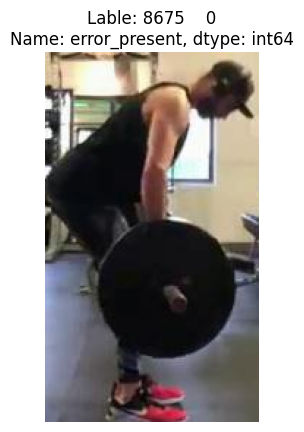

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\59698_3_77.jpg 0 / 1


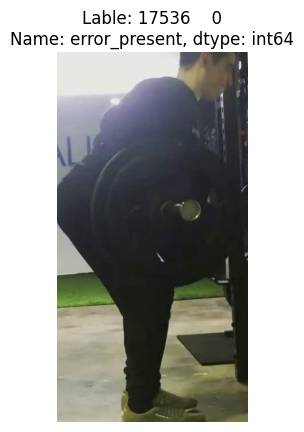

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\60733_1_23.jpg 0 / 1


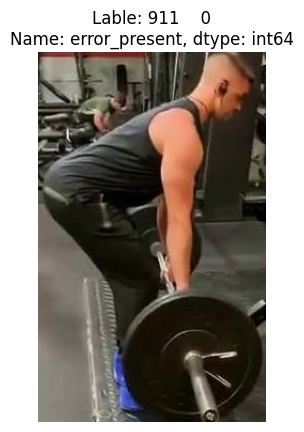

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\57108_1_8.jpg 0 / 1


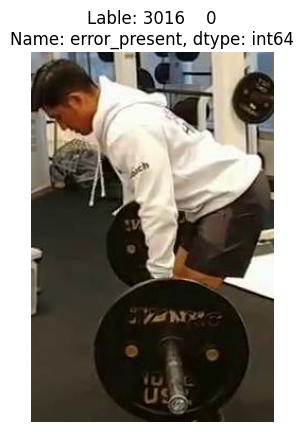

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\55866_3_4.jpg 0 / 1


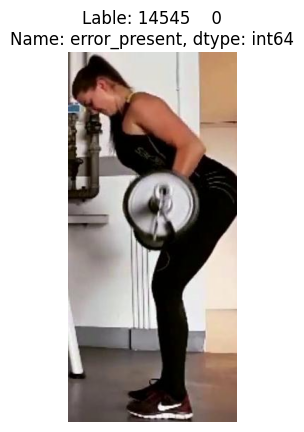

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\61775_5_26.jpg 0 / 1


In [28]:
# doing a random visual sanity check

sample_vids = frame_df['frame_path'].drop_duplicates().sample(5)

for vid in sample_vids:
    img = cv2.imread(vid)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    subset = frame_df[frame_df['frame_path'] == vid]
    plt.imshow(img)
    plt.title(f"Lable: {subset['error_present']}")
    plt.axis('off')
    plt.show()

    print(vid, subset['error_present'].sum(), "/",len(subset))

In [29]:
frame_df

,frame_id,error_present,video_name,frame_path,exists
0,59193_5_14,0,59193_5,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
1,59435_1_42,1,59435_1,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
2,53279_18_6,0,53279_18,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
3,61755_2_45,0,61755_2,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
4,59999_9_13,0,59999_9,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
...,...,...,...,...,...
18616,56273_1_16,1,56273_1,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
18617,60381_2_67,0,60381_2,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
18618,59343_5_39,1,59343_5,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
18619,61592_10_38,0,61592_10,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True


### Testing frame level binary classification only for barbell rows (ViT + MLP)


In [30]:
# step 1 : cleaning the dataframe
df = frame_df.copy()

df = df[df["exists"] == True].reset_index(drop=True)
df["error_present"] = df["error_present"].astype(int)

print(df["error_present"].value_counts())
print(df["error_present"].value_counts(normalize = True))

error_present
0    14629
1     3992
Name: count, dtype: int64
error_present
0    0.785618
1    0.214382
Name: proportion, dtype: float64


In [31]:
# step 1a keep only the videos that have at least one error frame
error_videos = (
    df.groupby("video_name")["error_present"]
    .max()
    .reset_index()
)

error_videos = error_videos[error_videos["error_present"] == 1]["video_name"]

df_error_videos_only = df[df["video_name"].isin(error_videos)].reset_index(drop=True)

print("Original frame:", len(df))
print("Filtered frames:", len(df_error_videos_only))
print("Original videos:", df["video_name"].nunique())
print("Filtered videos:", df_error_videos_only["video_name"].nunique())

print(df_error_videos_only["error_present"].value_counts())
print(df_error_videos_only["error_present"].value_counts(normalize=True))

Original frame: 18621
Filtered frames: 9189
Original videos: 1878
Filtered videos: 928
error_present
0    5197
1    3992
Name: count, dtype: int64
error_present
0    0.565568
1    0.434432
Name: proportion, dtype: float64


In [32]:
# step 2 - creating test train split by videos (not by frames)
df_trainval = df_error_videos_only

splitter = GroupShuffleSplit(
    n_splits = 1,
    test_size = 0.2,
    random_state = 42
)

train_idx, val_idx = next(
    splitter.split(df_trainval, groups=df_trainval["video_name"])
)

train_df = df_trainval.iloc[train_idx].reset_index(drop=True)
val_df = df_trainval.iloc[val_idx].reset_index(drop = True)

print("Train frames:", len(train_df))
print("Val Frames:", len(val_df))
print("Train videos:", train_df["video_name"].nunique())
print("Val videos:", val_df["video_name"].nunique())
print(train_df["error_present"].value_counts())
print(train_df["error_present"].value_counts(normalize = True))
print(val_df["error_present"].value_counts())
print(val_df["error_present"].value_counts(normalize = True))

Train frames: 7345
Val Frames: 1844
Train videos: 742
Val videos: 186
error_present
0    4137
1    3208
Name: count, dtype: int64
error_present
0    0.56324
1    0.43676
Name: proportion, dtype: float64
error_present
0    1060
1     784
Name: count, dtype: int64
error_present
0    0.574837
1    0.425163
Name: proportion, dtype: float64


In [33]:
# step 3 : creating Dataset class

class FrameDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["frame_path"]
        label = float(row["error_present"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [34]:
# step 4 : Vit for preprocessing

weights = ViT_B_16_Weights.IMAGENET1K_V1
transform = weights.transforms()

In [35]:
# step 5 : Data Loaders and Batching

BATCH_SIZE = 16

train_dataset = FrameDataset(train_df, transform=transform)
val_dataset = FrameDataset(val_df, transform = transform)

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers=0,
    pin_memory = True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers=0
)

In [36]:
# step 6: model creation (frozen ViT + trainable MLP) - Partially fine tuning of ViT

class FrozenViTFrameClassifier(nn.Module):
    def __init__(self, hidden_dim = 768, mlp_dim = 512, dropout = 0.4):
        super().__init__()

        self.vit = vit_b_16(weights = ViT_B_16_Weights.IMAGENET1K_V1)

        # remove original classifcation head
        self.vit.heads = nn.Identity()

        # freeze ViT
        for param in self.vit.parameters():
            param.requires_grad = False

        # unfreeze last transformer block
        for param in self.vit.encoder.layers[-1].parameters():
            param.requires_grad = True
        
        # trainable frame level classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, mlp_dim),
            nn.BatchNorm1d(mlp_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(mlp_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128,1)
        )

    def forward(self, x):
        # with torch.no_grad(): - as last ViT block is trainable
        features = self.vit(x) # batch of 768

        logits = self.classifier(features).squeeze(1)
        return logits

In [37]:
# step 7: training setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device", device)

model = FrozenViTFrameClassifier().to(device)

#criterion = nn.BCEWithLogitsLoss()

num_pos = (train_df["error_present"] == 1).sum()
num_neg = (train_df["error_present"] == 0).sum()

pos_weight = torch.tensor(
    [num_neg / num_pos], 
    dtype = torch.float32
    ).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight = pos_weight)

optimizer = torch.optim.AdamW(
    [
        {
            "params": model.vit.encoder.layers[-1].parameters(),
            "lr": 1e-5
        },
        {
            "params": model.classifier.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay = 1e-4
)

Using device cuda


In [38]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

vit.encoder.layers.encoder_layer_11.ln_1.weight
vit.encoder.layers.encoder_layer_11.ln_1.bias
vit.encoder.layers.encoder_layer_11.self_attention.in_proj_weight
vit.encoder.layers.encoder_layer_11.self_attention.in_proj_bias
vit.encoder.layers.encoder_layer_11.self_attention.out_proj.weight
vit.encoder.layers.encoder_layer_11.self_attention.out_proj.bias
vit.encoder.layers.encoder_layer_11.ln_2.weight
vit.encoder.layers.encoder_layer_11.ln_2.bias
vit.encoder.layers.encoder_layer_11.mlp.0.weight
vit.encoder.layers.encoder_layer_11.mlp.0.bias
vit.encoder.layers.encoder_layer_11.mlp.3.weight
vit.encoder.layers.encoder_layer_11.mlp.3.bias
classifier.0.weight
classifier.0.bias
classifier.1.weight
classifier.1.bias
classifier.4.weight
classifier.4.bias
classifier.5.weight
classifier.5.bias
classifier.8.weight
classifier.8.bias


In [39]:
# step 8: training loop

def train_one_epoch(model, loader, optimizer, criterion, device, epoch = None):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(loader, desc=f"Training Epoch {epoch}", leave=True)

    for batch_idx, (images, labels) in enumerate(progress_bar):
        images = images.to(device)
        labels = labels.to(device)

        if batch_idx == 0 and epoch == 1:
            print("Image Dev:", images.device)
            print("Model device:", next(model.parameters()).device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).int()

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        current_loss = running_loss / len(all_labels)
        current_acc = accuracy_score(all_labels, all_preds)

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_acc:.4f}"
        })

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [40]:
# Step 9: Evals 

def evaluate(model, loader, criterion, device, threshold = 0.5, epoch=None):
    model. eval()

    running_loss = 0.0
    all_probs = []
    all_preds = []
    all_labels = []

    progress_bar = tqdm(loader, desc=f"Validation epoch {epoch}", leave = True)

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device, non_blocking = True)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)
            
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).int()

            running_loss += loss.item() * images.size(0)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            current_loss = running_loss/len(all_labels)
            current_acc = accuracy_score(all_labels, all_preds)

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })

        avg_loss = running_loss / len(loader.dataset)

        all_preds = np.array(all_preds).astype(int)
        all_labels = np.array(all_labels).astype(int)
        all_probs = np.array(all_probs)
        
        acc = accuracy_score(all_labels, all_preds)
        cm = confusion_matrix(all_labels, all_preds)

        return avg_loss, acc, cm ,all_labels, all_preds, all_probs

In [41]:
# testing pre training

img, label = train_dataset[0]

print(img.shape)
print(label)

torch.Size([3, 224, 224])
tensor(1.)


In [42]:
# testing dataloader

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16])


In [76]:
EPOCHS = 10

In [46]:
# step 10: training init

EPOCHS = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch(
        model, 
        train_loader,
        optimizer,
        criterion,
        device, 
        epoch = epoch
    )

    val_loss, val_acc, val_cm, y_true, y_pred, y_prob = evaluate(
        model,
        val_loader,
        criterion,
        device,
        epoch = epoch
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")
    print(f"Confusion matrix:")
    print(val_cm)
    print("-" * 50)

Training Epoch 1:   0%|          | 0/459 [00:00<?, ?it/s]

Image Dev: cuda:0
Model device: cuda:0


Validation epoch 1: 100%|██████████| 116/116 [01:12<00:00,  1.60it/s, loss=0.7704, acc=0.5624]



Epoch 1/10
Train loss: 0.7857 | Train acc: 0.5583
Val loss: 0.7704 | Val acc: 0.5624
Confusion matrix:
[[630 430]
 [377 407]]
--------------------------------------------------


Validation epoch 2: 100%|██████████| 116/116 [01:00<00:00,  1.91it/s, loss=0.7611, acc=0.5569]


...


Epoch 8/10
Train loss: 0.4406 | Train acc: 0.8253
Val loss: 0.8895 | Val acc: 0.5727
Confusion matrix:
[[581 479]
 [309 475]]
--------------------------------------------------


Validation epoch 9: 100%|██████████| 116/116 [01:00<00:00,  1.92it/s, loss=0.9580, acc=0.5526]



Epoch 9/10
Train loss: 0.3999 | Train acc: 0.8461
Val loss: 0.9580 | Val acc: 0.5526
Confusion matrix:
[[510 550]
 [275 509]]
--------------------------------------------------


Validation epoch 10: 100%|██████████| 116/116 [01:00<00:00,  1.91it/s, loss=1.0016, acc=0.5754]


Epoch 10/10
Train loss: 0.3658 | Train acc: 0.8636
Val loss: 1.0016 | Val acc: 0.5754
Confusion matrix:
[[639 421]
 [362 422]]
--------------------------------------------------


In [47]:
# final classification report and adding results back val_df/val_results, right after training

print(classification_report(
    y_true,
    y_pred,
    target_names=["Correct frame", "Error frame"]
))

val_results = val_df.copy()

val_results["error_probability"] = y_prob
val_results["prediction_error"] = y_pred.astype(bool)
val_results["true_error"] = val_results["error_present"].astype(bool)

val_results.head()

               precision    recall  f1-score   support

Correct frame       0.64      0.60      0.62      1060
  Error frame       0.50      0.54      0.52       784

     accuracy                           0.58      1844
    macro avg       0.57      0.57      0.57      1844
 weighted avg       0.58      0.58      0.58      1844



,frame_id,error_present,video_name,frame_path,exists,error_probability,prediction_error,true_error
0,55049_10_1,0,55049_10,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True,0.069777,False,False
1,61653_4_33,0,61653_4,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True,0.007262,False,False
2,55446_6_23,1,55446_6,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True,0.370145,False,True
3,59685_4_24,0,59685_4,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True,0.353638,False,False
4,53468_2_8,1,53468_2,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True,0.219396,False,True


In [48]:
torch.save(model.state_dict(), "frame_vit_MLP_model1.pth")

In [43]:
model = FrozenViTFrameClassifier()
model.load_state_dict(torch.load("frame_vit_MLP_model1.pth"))
model.to(device)
model.eval()

FrozenViTFrameClassifier(
  (vit): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          

In [44]:
# evaluating the laoded model to regain the variables

val_loss, val_acc, val_cm, y_true, y_pred, y_prob = evaluate(
        model,
        val_loader,
        criterion,
        device,
        epoch = "fine1"
    )

Validation epoch fine1: 100%|██████████| 116/116 [01:18<00:00,  1.48it/s, loss=1.0016, acc=0.5754]


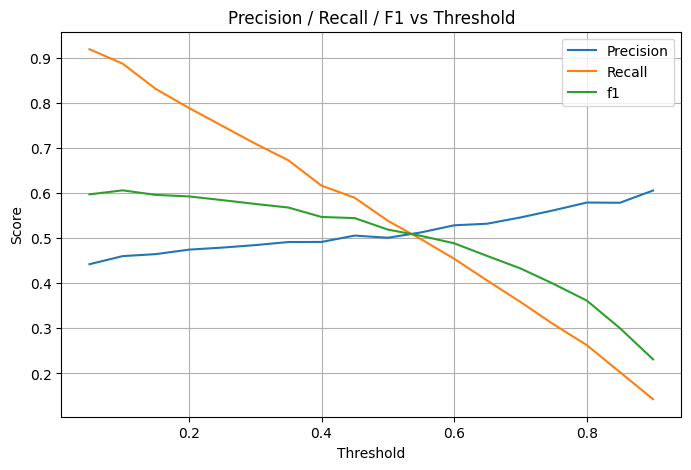

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.95, 0.05)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    precisions.append(precision_score(y_true, y_pred_t, zero_division = 0))
    recalls.append(recall_score(y_true, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_true, y_pred_t, zero_division = 0))

plt.figure(figsize = (8, 5))
plt.plot(thresholds, precisions, label = "Precision")
plt.plot(thresholds, recalls, label = "Recall")
plt.plot(thresholds, f1s, label = "f1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
# finding the best threshold 
best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1s[best_idx])
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])

Best threshold: 0.1
Best F1: 0.6056644880174292
Precision: 0.4599602911978822
Recall: 0.8864795918367347


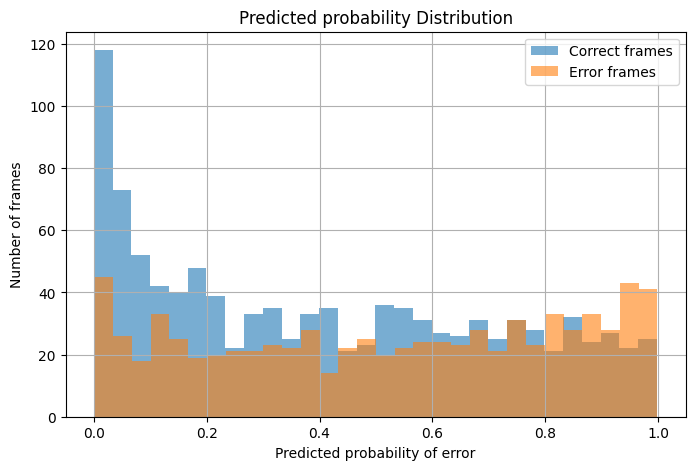

In [47]:
# plotting y_prob
plt.figure(figsize = (8,5))

plt.hist(
    y_prob[y_true == 0],
    bins = 30,
    alpha = 0.6,
    label = "Correct frames"
)

plt.hist(
    y_prob[y_true == 1],
    bins = 30,
    alpha = 0.6,
    label = "Error frames"
)

plt.xlabel("Predicted probability of error")
plt.ylabel("Number of frames")
plt.title("Predicted probability Distribution")
plt.legend()
plt.grid(True)
plt.show()

### Implementing Mediapipe + MLP

In [58]:
import mediapipe as mp

print(mp.__version__)
print(mp.__file__)
print(dir(mp))

0.10.35
d:\My Work\Computer Science Courses and Projects\Envs\DeepGPU\lib\site-packages\mediapipe\__init__.py
['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


In [59]:
BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

In [60]:
import urllib.request

model_url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task"
model_path = "pose_landmarker_lite.task"

urllib.request.urlretrieve(model_url, model_path)

('pose_landmarker_lite.task', <http.client.HTTPMessage at 0x1dcc20a68c0>)

In [61]:
options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.IMAGE,
    num_poses=1
)

landmarker = PoseLandmarker.create_from_options(options)

In [64]:
# mediapipe feature extractor


def extract_pose_features(image_path):
    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        return np.zeros(132, dtype=np.float32)
    
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format = mp.ImageFormat.SRGB,
        data=image_rgb
    )
    results = landmarker.detect(mp_image)

    if len(results.pose_landmarks) == 0:
        return np.zeros(132, dtype = np.float32)
    
    landmarks = results.pose_landmarks[0]

    features = []

    for lm in landmarks:
        features.extend([
            lm.x,
            lm.y,
            lm.z,
            lm.visibility
        ])
    
    return np.array(features, dtype = np.float32)


In [65]:
# setting the dataset class

class MediaPipeFrameDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop = True)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        features = extract_pose_features(row["frame_path"])
        label = float(row["error_present"])

        features = torch.tensor(features, dtype = torch.float32)
        label = torch.tensor(label, dtype = torch.float32)

        return features, label


In [66]:
features = extract_pose_features(train_df.iloc[0]["frame_path"])

print(features.shape)
print(features[:10])

(132,)
[ 0.65398073  0.14104953 -0.04720545  0.9875618   0.6665126   0.1207661
 -0.03814342  0.99120563  0.667296    0.11614034]


In [67]:
# Dataloaders

BATCH_SIZE = 32

train_dataset = MediaPipeFrameDataset(train_df)
val_dataset = MediaPipeFrameDataset(val_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers = 0,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers=0
)

In [73]:
# Pose classifier MLP

class MediaPipeMLPClassifier(nn.Module):
    def __init__(self, input_dim = 132):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        logits = self.classifier(x).squeeze(1)
        return logits

In [74]:
# training setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MediaPipeMLPClassifier().to(device)

num_pos = (train_df["error_present"] == 1).sum()
num_neg = (train_df["error_present"] == 0).sum()

pos_weight = torch.tensor(
    [num_neg / num_pos],
    dtype = torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight = pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = 1e-4,
    weight_decay = 1e-4
)

In [77]:
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        epoch=epoch
    )

    val_loss, val_acc, val_cm, y_true, y_pred, y_prob, = evaluate(
        model,
        val_loader,
        criterion,
        device,
        epoch = epoch
    )

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")
    print(val_cm)

Training Epoch 1:   0%|          | 0/229 [00:00<?, ?it/s]

Image Dev: cuda:0
Model device: cuda:0


Validation epoch 1: 100%|██████████| 58/58 [00:49<00:00,  1.17it/s, loss=0.7799, acc=0.5331]



Epoch 1/10
Train loss: 0.8019 | Train acc: 0.5162
val loss: 0.7799 | Val acc: 0.5331
[[667 393]
 [468 316]]


Validation epoch 2: 100%|██████████| 58/58 [00:42<00:00,  1.36it/s, loss=0.7777, acc=0.5049]


...


Epoch 8/10
Train loss: 0.7719 | Train acc: 0.5483
val loss: 0.7744 | Val acc: 0.5542
[[735 325]
 [497 287]]


Validation epoch 9: 100%|██████████| 58/58 [00:43<00:00,  1.33it/s, loss=0.7757, acc=0.5352]



Epoch 9/10
Train loss: 0.7713 | Train acc: 0.5520
val loss: 0.7757 | Val acc: 0.5352
[[705 355]
 [502 282]]


Validation epoch 10: 100%|██████████| 58/58 [00:43<00:00,  1.33it/s, loss=0.7722, acc=0.5672]


Epoch 10/10
Train loss: 0.7690 | Train acc: 0.5543
val loss: 0.7722 | Val acc: 0.5672
[[771 289]
 [509 275]]


In [79]:
# analyzing Mediapipe performance

def is_zero_pose(features):
    return np.all(features == 0)

zero_count = 0

for i in range(len(val_dataset)):
    features, label = val_dataset[i]
    if torch.all(features == 0):
        zero_count += 1

print("Zero-pose frames:", zero_count)
print("Total val frames:", len(val_dataset))
print("Zero-pose ratio:", zero_count/len(val_dataset))

Zero-pose frames: 587
Total val frames: 1844
Zero-pose ratio: 0.3183297180043384


In [81]:
# visuallising Mediapipe features

def show_frames_with_pose(image_path):
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr,cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format = mp.ImageFormat.SRGB,
        data = image_rgb
    )

    result = landmarker.detect(mp_image)

    plt.figure(figsize = (6,6))
    plt.imshow(image_rgb)

    if len(result.pose_landmarks) > 0:
        h, w, _ = image_rgb.shape
        landmarks = result.pose_landmarks[0]

        xs = [lm.x * w for lm in landmarks]
        ys = [lm.y * h for lm in landmarks]

        plt.scatter(xs, ys, s=10)

    plt.axis("off")
    plt.show()


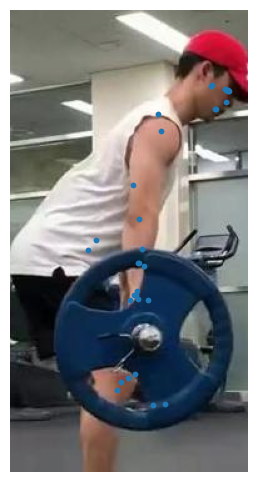

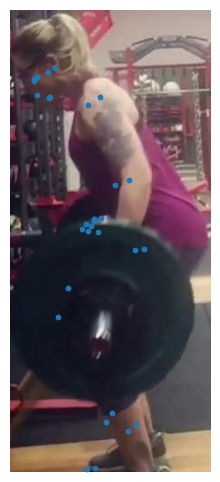

In [84]:
show_frames_with_pose(train_df.iloc[1]["frame_path"])
show_frames_with_pose(train_df[train_df["error_present"] == 1].iloc[2]["frame_path"])